# Music Data

Our edition project has been running for a very long time. Unfortunately, back in the 1980s most of the work was encoded using our own music notation data format. Now we need to use Verovio to render it. Since Verovio doesn't support our notation format, we need a Python script that can do the following:

1. Read in a text file with an encoded piece of music
2. Convert it to a format that Verovio understands
3. Have Verovio render that to SVG
4. Create an MEI file of our music notation

# Install Verovio

The first thing we need to do is ensure Verovio is installed in our virtual environment. We are going to use a tool called `pip` that downloads and installs Verovio for us. 

In [1]:
pip install verovio

  Obtaining dependency information for verovio from https://files.pythonhosted.org/packages/a7/23/25d6a382968815baf686099d519064c3444aaad7297b6e6c507c5608f225/verovio-6.3.0-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 45.6 MB/s eta 0:00:00:00:010:01

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Once we have Verovio installed, we can quickly verify that we have it installed and ready to go.

In [9]:
import verovio

tk = verovio.toolkit()
print(tk.getVersion())

6.3.0-425dd7b


If you see it print a version number like `6.3.0-425dd7b` (or similar) then you are good to go!

# Our target

We have a very important encoding of the first four measures of "Twinkle Twinkle Little Star." Before we look at the encoding, let's look at the rendering so that we can understand the kinds of notation features we can expect to support.

![Twinkle Twinkle](images/ttls.jpg)

<details>
<summary>List of features we need to support</summary>

- Clef
- Key signature
- Meter
- Notes with pitches, dots, durations
- Measures
- Beams
- Rests with durations
- Accidentals (+ / - / x )

</details>

# Our encoding

You can find the encoding in the sample-encodings/encoding.txt file, but let's look at what we have:

Let's take some time to compare our encoding with the rendered notation we have and understand how it works.

# Our program

Let's start by defining our data types.

In [2]:
from typing import Literal, TypedDict

# A TypedDict specifies a dictionary that must have these keys, and each key must have a specific value.
class StaffDefinition(TypedDict):
    clef: str
    keysig: str | None
    metersig: str

type Duration = int
# Accidentals can only be one of three values, so we use the "Literal" type to narrow it down
type Accidental = Literal["+", "-", "x"]

class Note(TypedDict):
    pname: str
    oct: int
    dur: Duration
    accid: Accidental | None
    dot: bool
    beamed: bool

class Rest(TypedDict):
    dur: Duration
    dot: bool

class Measure(TypedDict):
    events: list[Note | Rest]

class Score(TypedDict):
    definition: StaffDefinition
    measures: list[Measure]



Next, let's test our types by making a very simple example of a one note score

In [3]:
note: Note = {
    "pname": "C",
    "oct": 5,
    "dur": 4,
    "accid": None,
    "dot": False,
    "beamed": False
}

rest: Rest = {
    "dur": 2,
    "dot": True
}

staff_def: StaffDefinition = {
    "clef": "G-2",
    "keysig": None,
    "metersig": "4/4"
}

measure_one: Measure = {
    "events": [note, rest]
}

my_score: Score = {
    "definition": staff_def,
    "measures": [measure_one]
}

# Now you can look at your score and see what you have built!
print(my_score)

{'definition': {'clef': 'G-2', 'keysig': None, 'metersig': '4/4'}, 'measures': [{'events': [{'pname': 'C', 'oct': 5, 'dur': 4, 'accid': None, 'dot': False, 'beamed': False}, {'dur': 2, 'dot': True}]}]}


# Reading from a file

The encoding is available in sample-encodings/encoding.txt. We want to:

1. Open this file and read its contents
2. Process each line, and the contents of each line into our data structures
3. Build our score from this content

# Rendering with Verovio

We have a magic function that, if we can give it an object of type `Score`, Verovio can automatically render it to a SVG string.

In [4]:
import verovio
import json

def render(input: Score) -> str:
    """Takes a Score object and produces an image using Verovio.
        Internally, it takes our encoding format and produces a Plaine and Easie encoding
        since Verovio knows how to render that.
    """
    tk = verovio.toolkit()
    tk.setInputFrom("pae")
    tk.setOptions({
        "footer": "none",
        "header": "none",
        "adjustPageHeight": True
    })

    note_data: str = ""
    for measure in input["measures"]:
        events = measure["events"]
        for i, event in enumerate(measure["events"]):
            # We need to figure out beaming groups. Look at the previous, current, and next events.
            prev = events[i - 1] if i > 0 else None
            next = events[i + 1] if i < len(events) - 1 else None

            # If the previous one isn't beamed, but this one is, then we insert an open beam character
            if event.get("beamed", False) is True:
                # Now check if we either a) don't have a previous note, or b) we do have a previous note, but it wasn't beamed.
                # Only then do we need to emit a beam group.
                if not prev or prev and prev.get("beamed", False) is False:
                    note_data += "{"

            # Process the note data normally.
            note_data += _process_event(event)

            # If the next one isn't beamed, but this one is, then we insert a close beam character
            if event.get("beamed", False) is True and (next and next.get("beamed", False) is False):
                note_data += "}"

        # After all events have been processed, but before we end the
        # measure loop, add a barline.
        note_data += "/"

    pae_dict: dict = {
        "clef": input["definition"]["clef"],
        "keysig": input["definition"]["keysig"],
        "timesig": input["definition"]["metersig"],
        "data": note_data
    }

    tk.loadData(json.dumps(pae_dict))
    svg_out: str = tk.renderToSVG()
    return svg_out


def _process_event(ev: Note | Rest) -> str:
    pae_event: str = ""
    # Both have a duration, so we can deal with that here.
    dur: str = str(ev["dur"])

    # Both notes and rests can have a dot
    dot_value = ev["dot"]
    dot_pae: str = ""
    if dot_value:
        dot_pae = "."

    if "pname" not in ev:
        # only notes have pnames, so this is a rest
        pae_event += dur
        pae_event += dot_pae
        pae_event += "-"
        return pae_event

    # The octave indicator is ' for octave 4+, and , for <4. 
    # We can multiply a string to get that many copies of it.
    # So for the 4th octave we get 4 - 3 = 1 * '; for the 5th octave: 5 - 3 = 2*', and so on. 
    # Same for the lower octaves. 
    if ev["oct"] >= 4:
        num_oct = "'" * (ev["oct"] - 3)
    else:
        num_oct = "," * (ev["oct"] - 2)

    pae_event += num_oct

    # Add the duration.
    pae_event += dur
    pae_event += dot_pae

    # We need to convert accidentals
    accid_val: str | None = ev["accid"]
    # dictionaries are handy ways of mapping one value to another.
    accid_map: dict = {
        "x": "xx",
        "+": "x",
        "-": "b"
    }
    if accid_val:
        # It's not None
        pae_event += accid_map[accid_val]

    pname_val: str = ev["pname"]
    pae_event += pname_val

    return pae_event


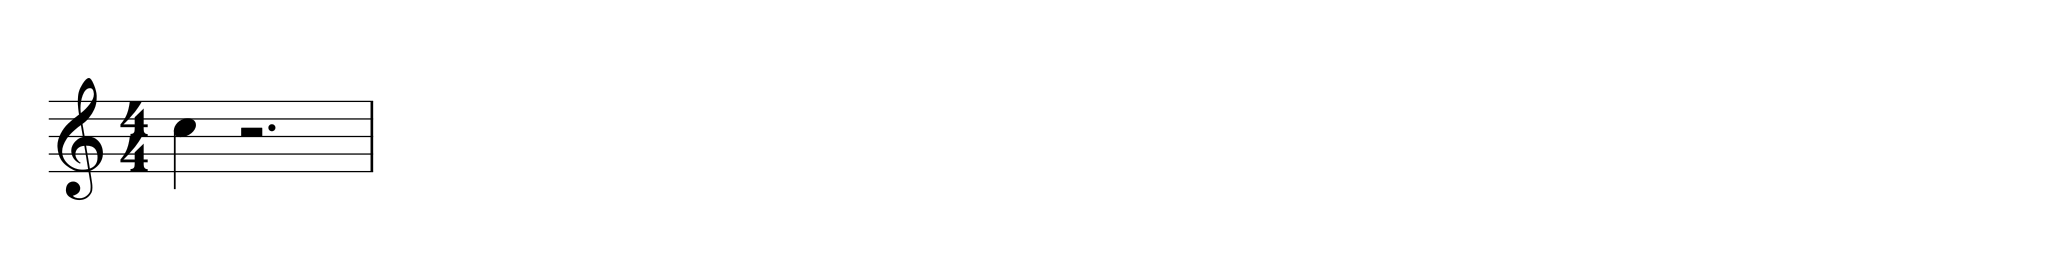

In [5]:
svg_output: str = render(my_score)

from IPython.display import SVG, display
display(SVG(svg_output))

# Quick Pause for Review

OK, by this point you should have a small Verovio rendering of a single note and a rest. It's worth pausing here to review what you have done so far. Try playing with some of the parameters in our small sample encoding, or add another note or a rest to see the effect.

It is also worth looking through the code in our `render` function to see what parts you understand, and where you might need further explanation or clarification.

# Rendering our file

Now we have a data structure, and the ability to render it. The last step is to open and read the data from our file and convert it into our data structures.

There is no real magic here. Python has some methods that can make this job easier, but the best way to do it is to break it down into steps.



In [ ]:
# 1. Read the file and extract the lines
with open("sample-encodings/encdoding.txt") as my_encoding:
    # Use the `readlines()` method on my_encoding to get a list of the lines in a file.
    file_contents: list[str] = ... 

# 2. When you read lines in, you will get the end of line character (\n)
# and any empty lines. This list comprehension will also use the truthiness of an empty
# string to filter out blank lines, leaving only the contents.
cleaned_contents: list[str] = [l.strip() for l in file_contents if l.strip()]

In [ ]:
# 2. Iterate through the lines in our cleaned contents and determine whether it is a
# definition line (starts with ---) or a measure line (starts with [). 
# Fill in the for loop.

# 2a: Define two functions that parse the string and produce either a StaffDefinition or a Measure
def make_staff_definition(line_input: str) -> StaffDefinition: ...

def make_measure(line_input: str) -> Measure: ...

# 2b: Loop through the contents of our file and build your data structure.
# Hint: Remember to save your results outside of the loop!
staff_def: StaffDefinition
measures: list[Measure]

# Replace in "something" and the empty list with the appropriate bits of data
for something in []:
    if something.startswith("--"):
        # what do we have here?
        pass
    elif something.startswith("["):
        # what do we have here?
        pass
    else:
        # If it doesn't match either, what should we do??
        pass

# 3. Create your score from the processed values
encoding: Score

# 4. Pass it over to Verovio to render
rendered_svg = render(encoding)
from IPython.display import SVG, display
display(SVG(svg_output))


# Make a Python file

Now that we have a solution, you should copy the code from this notebook into a Python file and run it on the command-line. You will not be able to see the SVG on the command-line, but you can write the output to a file.

# Solutions

If you get stuck, you can look at `verovio_solution.ipynb` for the Notebook version of the solution, and `verovio_solution.py` for the full Python file. 